# P2C3: Classifiez avec la Régression Logistique


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/blob/master/notebooks/P2C4_partitionnez_kmean.ipynb)



In [ ]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


## Créer un dataset partitionné

Pour créer un dataset artificiel en 2 dimensions constitué de K clusters de N échantillons chacun, scikit-learn offre la fonction make_blob().

Par exemple voici 3 "blobs" bien séparés constitués de 3000 échantillons  chacun n_samples=3000, centrés respectivement aux coordonnées centers = [[2, 2], [-2, -2], [2, -2]]  et d'écart type cluster_std=0.7 .




In [18]:

centers = [[2, 2], [-2, -2], [2, -2]]
X, labels_true = make_blobs(
                      n_samples=3000, 
                      centers=centers, 
                      cluster_std=0.7)


In [19]:
# dimension 3000 x 2
X.shape

(3000, 2)

In [20]:
labels_true

array([2, 1, 2, ..., 2, 2, 2], shape=(3000,))

In [21]:
# de dimension 3000
len(labels_true)

3000

## Visualisation

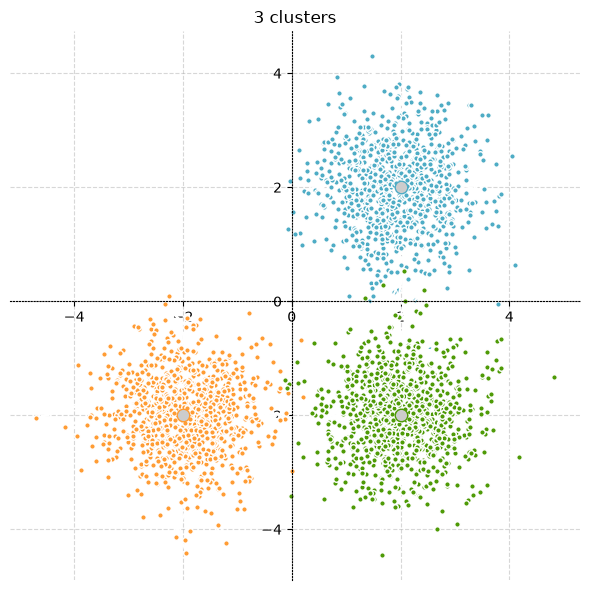

In [22]:
    centers = [[2, 2], [-2, -2], [2, -2]]
    X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.7)
    n_clusters = len(centers)
    fig = plt.figure(figsize=(6, 6))
    colors = ["#4EACC5", "#FF9C34", "#4E9A06"]

    # KMeans
    ax = fig.add_subplot(1, 1, 1)

    ax.set_title("3 clusters")

    for k, col in zip(range(len(centers)), colors):
        my_members = labels_true == k
        ax.plot(X[my_members, 0], X[my_members, 1], "w", markerfacecolor=col, marker="o", markersize=4, alpha = 1)
    for k, col in zip(range(len(centers)), colors):
        ax.plot(
            centers[k][0],
            centers[k][1],
            "o",
            markerfacecolor='#CCC',
            markeredgecolor=col,
            markersize=9,
        )
    # ax.set_title("Original")
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_linestyle('dotted')
    ax.spines['left'].set_linestyle('dotted')

    # Customize the appearance of grid lines (dotted and alpha=0.5)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    # Remove the top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()


## Appliquons le k-means()

In [23]:

k_means = KMeans( n_clusters=3, random_state = 808, n_init = 'auto')
k_means.fit(X)
print(k_means.cluster_centers_)

[[ 1.9982857  -2.00340461]
 [-1.97698289 -2.00423731]
 [ 1.92441878  1.9898292 ]]


On obtient les centres suivant: [-2.02 -2.00], [ 1.99  2.01], [ 1.98 -2.01] soit très proches des centres initiaux de nos données: [2, 2], [-2, -2], [2, -2]

### Visualisation

[[ 2.01014743  1.99360834]
 [ 1.96010701 -2.04252035]
 [-1.99882866 -1.97726374]]
score -4673.577803207578
silhouette_score:  0.5907298716991993
silhouette_score:  0.582464200176339


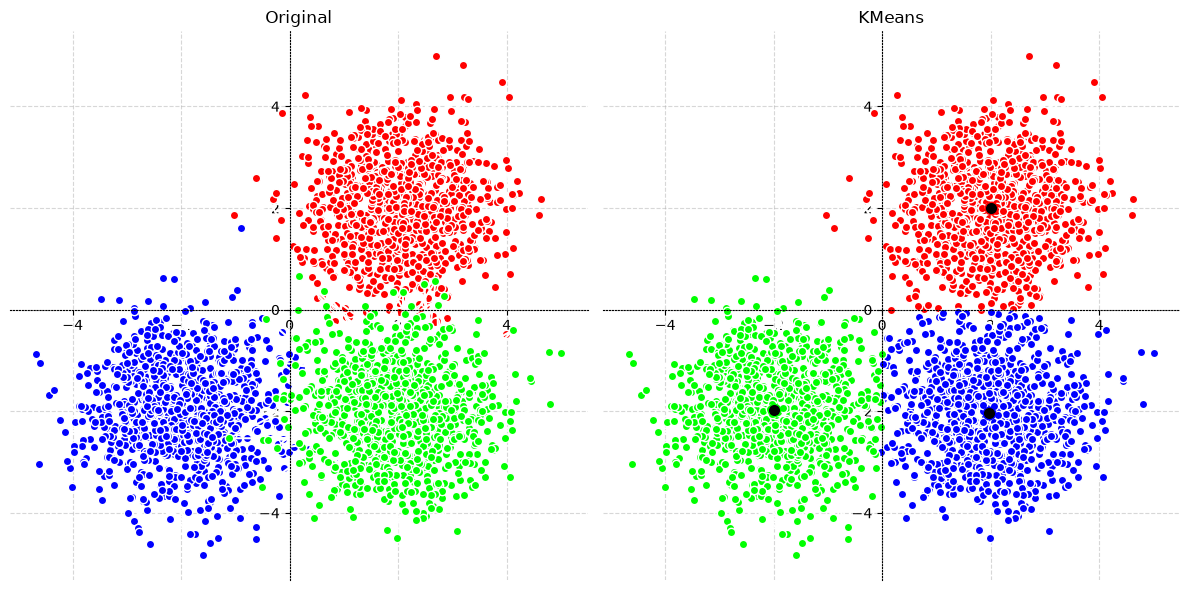

In [ ]:
centers = [[2, 2], [-2, -2], [2, -2]]
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.9)

from sklearn.cluster import KMeans
n_clusters=3
k_means = KMeans(init="k-means++", n_clusters=n_clusters, random_state = 808 , n_init = 'auto'  )
k_means.fit(X)
print(k_means.cluster_centers_)
print("score", k_means.score(X))

from sklearn.metrics import silhouette_score
k_means_labels = k_means.predict(X)
print("silhouette_score: ", silhouette_score(X,k_means_labels ))
print("silhouette_score: ", silhouette_score(X,labels_true ))


fig = plt.figure(figsize=(12, 6))
colors = ["#4EACC5", "#FF9C34", "#4E9A06","#111111"]
colors = ["#FF0000", "#0000FF", "#00FF00","#111111"]

# KMeans
ax = fig.add_subplot(1, 2, 1)

# for k, col in zip(range(n_clusters), colors):
for k in range(n_clusters):
    ax.plot(X[labels_true == k, 0], X[labels_true == k, 1], "w", markerfacecolor=colors[k], marker="o", markersize=6, alpha = 1)

ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_linestyle('dotted')
ax.spines['left'].set_linestyle('dotted')

# Customize the appearance of grid lines (dotted and alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("Original")

ax = fig.add_subplot(1, 2, 2)
for k in range(n_clusters):
    cluster_center = k_means.cluster_centers_[k]
    ax.plot(X[k_means_labels == k, 0], X[k_means_labels == k, 1], "w", markerfacecolor=colors[k], marker="o", markersize=6, alpha = 1)
for k in range(n_clusters):
    cluster_center = k_means.cluster_centers_[k]
    ax.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor='#000',
        markeredgecolor=colors[k],
        markersize=9,
    )
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_linestyle('dotted')
ax.spines['left'].set_linestyle('dotted')

# Customize the appearance of grid lines (dotted and alpha=0.5)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
# Remove the top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title("KMeans")
plt.tight_layout()
plt.show()


# Coefficient de Silhouette

In [25]:
from sklearn.metrics import silhouette_score
k_means_labels = k_means.predict(X)
print("silhouette_score: ", silhouette_score(X,k_means_labels ))

silhouette_score:  0.5907298716991993


## Selection du nombre de clusters optimal avec le coefficient de Silhouette


n_clusters 2
score -12287.801611273258
silhouette_score:  0.4840488203182037

n_clusters 3
score -4686.453172425983
silhouette_score:  0.5915704167921244

n_clusters 4
score -4111.102194131286
silhouette_score:  0.4749396397756824

n_clusters 5
score -3550.751695295575
silhouette_score:  0.37252579545603515

n_clusters 6
score -3100.9453350729664
silhouette_score:  0.3054530087661314

n_clusters 7
score -2753.6542902180913
silhouette_score:  0.31188806165359945


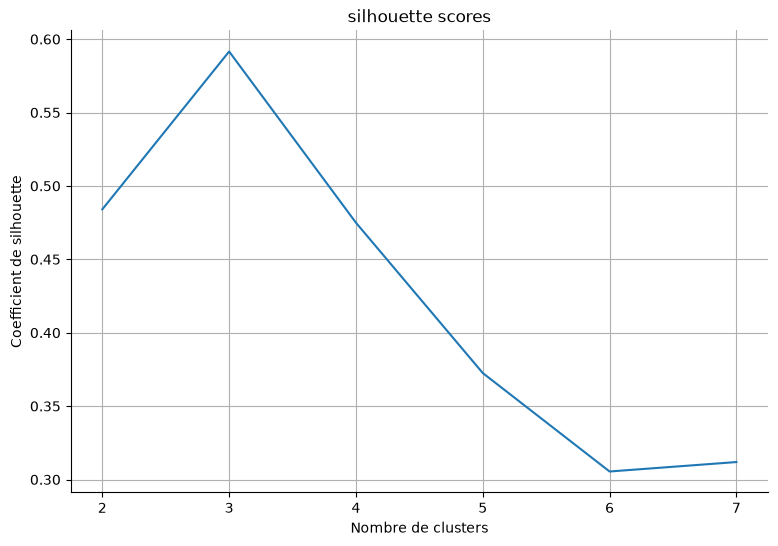

In [ ]:
centers = [[2, 2], [-2, -2], [2, -2]]
X, labels_true = make_blobs(n_samples=3000, centers=centers, cluster_std=0.9)

silhouette_scores = []
for n_clusters in range(2,8):
    print()
    print("n_clusters",n_clusters)
    k_means = KMeans(init="k-means++", n_clusters=n_clusters, random_state = 808 , n_init = 'auto'  )
    k_means.fit(X)
    print("score", k_means.score(X))

    k_means_labels = k_means.predict(X)
    print("silhouette_score: ", silhouette_score(X,k_means_labels ))
    silhouette_scores.append(silhouette_score(X,k_means_labels ))

fig = plt.figure(figsize=(9, 6))

ax = fig.add_subplot(1, 1, 1)
plt.plot(range(2,8), silhouette_scores)
ax.set_title('silhouette scores')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('Nombre de clusters')
ax.set_ylabel('Coefficient de silhouette')
plt.grid()
plt.show()

On observe bien un pic de la valeur du coefficient pour 3 clusters.

# Appliquez le k-means sur Iris

In [27]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data
y = iris.target

In [28]:
model = KMeans(n_clusters=3, n_init="auto")
model.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](3, 4)",

In [29]:
# Voici les scores de classification
print("score", model.score(X))
print("silhouette_score: ", silhouette_score(X,model.labels_ ))


score -78.85144142614601
silhouette_score:  0.5528190123564095


## performance du clustering en tant qu'outil de classification

In [30]:
from sklearn.metrics import confusion_matrix

labels = model.labels_.copy()
print("confusion_matrix",confusion_matrix(y,labels ))
print(set(labels))

confusion_matrix [[ 0 50  0]
 [48  0  2]
 [14  0 36]]
{np.int32(0), np.int32(1), np.int32(2)}


In [31]:
# Match categories de kmeans avec les bonnes  categories du dataset
labels = model.labels_.copy()
# temp values
labels[labels==0] = 5
labels[labels==1] = 10
labels[labels==2] = 15

# Bonnes catégories
labels[labels == 5] = 0
labels[labels == 10] = 2
labels[labels == 15] = 1

In [32]:

print("confusion_matrix\n",confusion_matrix(y,labels ))

confusion_matrix
 [[ 0  0 50]
 [48  2  0]
 [14 36  0]]


In [33]:
from sklearn.metrics import accuracy_score

print("accuracy_score",accuracy_score(y,labels ))


accuracy_score 0.013333333333333334


Donc une performance assez bonne avec une précision de 88,7%.

La matrice de confusion montre que la catégorie 1 est identifiée à 100% 

Les catégories 2 et 3 sont en majorité aussi bien identifiées.
